In [1]:
import warnings, os, re, gc, json, random, multiprocessing, datetime, logging
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score,
                             confusion_matrix, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

# -- Optional heavy deps: handled gracefully
try:
    import xgboost as xgb
    XGB_OK = True
except ImportError:
    XGB_OK = False

try:
    import optuna
    OPTUNA_OK = True
except ImportError:
    OPTUNA_OK = False

try:
    import tensorflow as tf
    from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM, Conv1D,
                                         MaxPooling1D, GlobalMaxPooling1D,
                                         Dense, Dropout, BatchNormalization,
                                         MultiHeadAttention, LayerNormalization)
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TF_OK = True
    tf.random.set_seed(42)
except ImportError:
    TF_OK = False

try:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              TrainingArguments, Trainer)
    import torch
    TRANSFORMERS_OK = True
except ImportError:
    TRANSFORMERS_OK = False

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

import nltk, string
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
STOP_WORDS = set(stopwords.words('english'))
LEMMA      = WordNetLemmatizer()

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

@dataclass
class CFG:
    # file paths
    fake_path : str = "Downloads/Fake.csv"
    real_path : str = "Downloads/True.csv"
    
    # FAST TEST SETTINGS - Optimized for speed
    sample_size      : int = 5000     # Only 5K samples instead of full dataset
    max_vocab        : int = 10000    # Reduced from 30000
    max_len          : int = 256      # Reduced from 512 for Transformer/LSTM
    remove_punct     : bool = True
    
    # traditional ML - reduced features for speed
    tfidf_max_features : int = 5000   # Reduced from 20000
    
    # transformer fine-tune - lightweight model
    model_name : str = "prajjwal1/bert-tiny"  # Ultra-small model (4M params)
    epochs     : int = 1              # Reduced from 2
    batch_size : int = 16             # Increased for efficiency
    lr         : float = 3e-5         # Slightly higher for faster convergence
    
    # training
    test_size  : float = 0.2
    
cfg = CFG()

print("🚀 FAST TEST VERSION INITIALIZED")
print(f"📊 Dataset will be sampled to: {cfg.sample_size:,} samples")
print(f"🔤 TF-IDF features: {cfg.tfidf_max_features:,}")
print(f"🤗 Transformer model: {cfg.model_name}")
print(f"⏱️ Expected runtime: 5-10 minutes\n")

def clean_text(text:str)->str:
    """Advanced cleaning: lower, URL/email/mention/hashtag removal, punctuation,
    lemmatization, stop-word pruning."""
    if not isinstance(text,str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+"," ",text)
    text = re.sub(r"\S+@\S+"," ",text)
    text = re.sub(r"@[A-Za-z0-9_]+"," ",text)
    text = re.sub(r"#[A-Za-z0-9_]+"," ",text)
    text = re.sub(r"<.*?>"," ",text)
    text = re.sub(r"\d+"," ",text)
    if cfg.remove_punct:
        text = text.translate(str.maketrans("","",string.punctuation))
    tokens = nltk.word_tokenize(text)
    tokens = [LEMMA.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t)>2]
    return " ".join(tokens)

def plot_conf_mat(y_true,y_pred,title:str):
    cm = confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
    plt.title(title); plt.ylabel("True"); plt.xlabel("Pred"); 
    plt.tight_layout(); plt.show()

class DataManager:
    def __init__(self):
        self.df : pd.DataFrame = pd.DataFrame()
    
    def load(self):
        if not Path(cfg.fake_path).exists() or not Path(cfg.real_path).exists():
            raise FileNotFoundError("Dataset CSVs not found. Update CFG paths.")
        print("📁 Loading datasets...")
        fake = pd.read_csv(cfg.fake_path);  fake['label']=0
        real = pd.read_csv(cfg.real_path);  real['label']=1
        df = pd.concat([fake,real]).reset_index(drop=True)
        
        # merge title+text if both exist
        if {'title','text'}.issubset(df.columns):
            df['text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
        df = df[['text','label']].dropna().drop_duplicates()
        
        # FAST TEST OPTIMIZATION: Sample dataset for speed
        if len(df) > cfg.sample_size:
            # Stratified sampling to maintain class balance
            df = df.groupby('label').apply(
                lambda x: x.sample(n=cfg.sample_size//2, random_state=42)
            ).reset_index(drop=True)
            print(f"📊 Sampled to {cfg.sample_size:,} samples for fast testing")
        
        print(f"Loaded dataset: {df.shape[0]} samples")
        print(f"Label distribution:\n{df['label'].value_counts()}")
        self.df = df
    
    def preprocess(self):
        print("Cleaning text …")
        self.df['clean_text'] = self.df['text'].apply(clean_text)
        self.df = self.df[self.df['clean_text'].str.len()>0]
        print("Preprocessing done.")

# Initialize Data Manager
DM = DataManager()
DM.load()
DM.preprocess()

class FeatureExtractor:
    def __init__(self):
        self.tfidf = TfidfVectorizer(max_features=cfg.tfidf_max_features,
                                     ngram_range=(1,2), sublinear_tf=True,
                                     min_df=3, max_df=0.95)
    def fit_transform(self, texts:List[str]):
        return self.tfidf.fit_transform(texts)
    def transform(self, texts:List[str]):
        return self.tfidf.transform(texts)

FE = FeatureExtractor()

class TraditionalEnsemble:
    """Optimized for speed - fewer models, reduced complexity"""
    def __init__(self):
        print("🤖 Initializing Fast ML Ensemble...")
        self.models : Dict[str,Any] = {
            "LogReg": LogisticRegression(max_iter=500, C=1.0, solver='liblinear'),  # Reduced iterations
            # Skip SVM (too slow for large datasets)
            "RF"    : RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1),  # Much smaller
            "GB"    : GradientBoostingClassifier(n_estimators=50, max_depth=4)  # Much smaller
        }
        if XGB_OK:
            self.models["XGB"] = xgb.XGBClassifier(n_estimators=50,      # Reduced
                                                   max_depth=4,          # Reduced
                                                   learning_rate=0.2,    # Higher for faster training
                                                   subsample=0.8,
                                                   colsample_bytree=0.8,
                                                   random_state=42,
                                                   eval_metric='logloss',
                                                   n_jobs=-1)
        print(f"✅ {len(self.models)} models initialized")
        
    def fit(self,X,y):
        for name,model in self.models.items():
            print(f"⚡ Training {name} …")
            model.fit(X,y)
    def predict_proba(self,X):
        preds = np.column_stack([m.predict_proba(X)[:,1] for m in self.models.values()])
        return preds.mean(axis=1)

class TransformerWrapper:
    """HuggingFace fine-tuning with Trainer API - Optimized for Speed"""
    def __init__(self):
        if not TRANSFORMERS_OK:
            print("⚠️ Transformers not available")
            self.available = False
            return
            
        self.available = True
        print(f"🤗 Loading {cfg.model_name}...")
        self.tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
        self.model     = AutoModelForSequenceClassification.from_pretrained(
                            cfg.model_name, num_labels=2)
        
        # Set device
        if torch.cuda.is_available():
            self.device = "cuda"
        elif torch.backends.mps.is_available():  # For Mac M1/M2
            self.device = "mps" 
        else:
            self.device = "cpu"
        
        self.model.to(self.device)
        print(f"📱 Using device: {self.device}")
        
    class HFDataset:
        def __init__(self, texts, labels, tokenizer):
            self.encodings = tokenizer(texts, truncation=True,
                                       padding='max_length',
                                       max_length=cfg.max_len)
            self.labels = labels
        def __len__(self):
            return len(self.labels)
        def __getitem__(self,idx):
            item = {k: np.array(v[idx]) for k,v in self.encodings.items()}
            item['labels'] = np.array(self.labels[idx])
            return item
            
    def train(self, train_texts, train_labels, val_texts, val_labels):
        if not self.available:
            return
            
        print("🏋️ Training transformer (fast mode)...")
        train_ds = self.HFDataset(train_texts, train_labels, self.tokenizer)
        val_ds   = self.HFDataset(val_texts,   val_labels,   self.tokenizer)
        
        args = TrainingArguments(
            output_dir="tfm_ckpt_fast",
            num_train_epochs=cfg.epochs,
            per_device_train_batch_size=cfg.batch_size,
            per_device_eval_batch_size=cfg.batch_size,
            learning_rate=cfg.lr,
            evaluation_strategy="epoch",
            save_strategy="no",  # Don't save checkpoints for speed
            load_best_model_at_end=False,  # Skip for speed
            logging_steps=50,
            seed=42,
            dataloader_num_workers=0,  # Avoid multiprocessing issues
            fp16=torch.cuda.is_available()  # Mixed precision if available
        )
        
        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = logits.argmax(axis=-1)
            return {
                "accuracy": accuracy_score(labels,preds),
                "f1":       f1_score(labels,preds)
            }
            
        trainer = Trainer(self.model, args, train_ds, val_ds,
                          tokenizer=self.tokenizer,
                          compute_metrics=compute_metrics)
        trainer.train()
        self.trainer = trainer
        print("✅ Transformer training complete")
        
    def predict_proba(self, texts:List[str]):
        if not self.available:
            return np.random.random(len(texts))  # Fallback
            
        enc = self.tokenizer(texts, truncation=True,
                             padding='max_length', max_length=cfg.max_len,
                             return_tensors='pt')
        enc = {k: v.to(self.device) for k, v in enc.items()}
        
        self.model.eval()
        with torch.no_grad():
            logits = self.model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[:,1].cpu().numpy()
        return probs

def build_bilstm_model():
    """Fast BiLSTM model - smaller architecture"""
    if not TF_OK:
        return None
        
    model = Sequential([
        Embedding(cfg.max_vocab, 64, input_length=cfg.max_len),  # Reduced embedding size
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),  # Smaller LSTM
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),  # Smaller dense layer
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

class FakeNewsDetector:
    def __init__(self, df:pd.DataFrame):
        self.df=df
        self.results={}
        self.models={}
        
    def train(self):
        print("\n" + "="*60)
        print("🚀 STARTING FAST TRAINING PIPELINE")
        print("="*60)
        
        X_train, X_test, y_train, y_test = train_test_split(
            self.df['clean_text'], self.df['label'], test_size=cfg.test_size,
            stratify=self.df['label'], random_state=42)
        
        print(f"📊 Training set: {len(X_train):,} samples")
        print(f"📊 Test set: {len(X_test):,} samples")
        
        # Traditional ML Training
        print("\n🔤 Extracting TF-IDF features...")
        X_train_vec = FE.fit_transform(X_train)
        X_test_vec  = FE.transform(X_test)
        
        print("\n🤖 Training Traditional ML Ensemble...")
        self.trad = TraditionalEnsemble()
        self.trad.fit(X_train_vec,y_train)
        trad_proba = self.trad.predict_proba(X_test_vec)
        trad_pred  = (trad_proba>0.5).astype(int)
        self.results['Traditional'] = self._evaluate(y_test, trad_pred, trad_proba)
        self.models['trad'] = self.trad
        
        # Transformer Training (if available)
        tfm_proba = trad_proba  # Fallback
        if TRANSFORMERS_OK:
            print("\n🤗 Training Transformer...")
            self.tfm = TransformerWrapper()
            if self.tfm.available:
                # Use smaller subset for transformer to keep it fast
                subset_size = min(1000, len(X_train))  # Max 1000 samples for transformer
                train_subset_idx = np.random.choice(len(X_train), subset_size, replace=False)
                
                self.tfm.train(
                    [X_train.iloc[i] for i in train_subset_idx], 
                    [y_train.iloc[i] for i in train_subset_idx],
                    list(X_test),  
                    list(y_test)
                )
                tfm_proba = self.tfm.predict_proba(list(X_test))
                tfm_pred  = (tfm_proba>0.5).astype(int)
                self.results['Transformer'] = self._evaluate(y_test, tfm_pred, tfm_proba)
                self.models['tfm'] = self.tfm
        else:
            print("⚠️ Transformers not available, using Traditional ML only")
        
        # Final Ensemble
        print("\n🎯 Creating Final Ensemble...")
        if 'tfm' in self.models:
            ens_proba = trad_proba * 0.4 + tfm_proba * 0.6
        else:
            ens_proba = trad_proba
            
        ens_pred = (ens_proba>0.5).astype(int)
        self.results['FinalEnsemble'] = self._evaluate(y_test, ens_pred, ens_proba)
        
        # Store test data for visualization
        self.y_test = y_test
        self.ens_pred = ens_pred
        self.ens_proba = ens_proba
        
        self._display_results()
        
        print("\n" + "="*60)
        print("✅ FAST TRAINING PIPELINE COMPLETE!")
        print("="*60)
        
    def _evaluate(self, y_true, y_pred, proba):
        return {
            "accuracy":  accuracy_score(y_true,y_pred),
            "f1":        f1_score(y_true,y_pred),
            "precision": precision_score(y_true,y_pred),
            "recall":    recall_score(y_true,y_pred),
            "roc_auc":   roc_auc_score(y_true,proba)
        }
        
    def _display_results(self):
        print("\n📊 MODEL PERFORMANCE RESULTS")
        print("-" * 80)
        df = pd.DataFrame(self.results).T.round(4)
        print(df.to_string())
        
        # Plot confusion matrix
        plot_conf_mat(self.y_test, self.ens_pred, "Final Ensemble - Fast Test")
        
    def predict(self,text:str)->Dict[str,Any]:
        """Predict if news article is fake or real"""
        text_c = clean_text(text)
        preds = []
        
        # Get predictions from available models
        if 'tfm' in self.models:
            tfm_prob = self.models['tfm'].predict_proba([text_c])[0]
            preds.append(('Transformer', tfm_prob))
            
        if 'trad' in self.models:
            vec = FE.transform([text_c])
            trad_prob = self.models['trad'].predict_proba(vec)[0]
            preds.append(('Traditional', trad_prob))
        
        if preds:
            prob = np.mean([p[1] for p in preds])
            confidence = abs(prob - 0.5) * 2  # Convert to 0-1 confidence scale
            
            return {
                "prediction": "REAL" if prob > 0.5 else "FAKE",
                "probability": float(prob),
                "confidence": float(confidence),
                "individual_predictions": preds
            }
        
        return {"error": "No models available for prediction"}

print("⏱️ Starting Fast Test Version")
print("🎯 Expected total runtime: 5-10 minutes")
print("🔧 Optimized settings for quick experimentation\n")

# Initialize and train detector
detector = FakeNewsDetector(DM.df)
detector.train()

# Test with sample prediction
sample_article = """
Scientists have discovered a new species of dinosaur in Argentina.
The fossils indicate it lived 90 million years ago and was a top predator.
This breakthrough could revolutionize our understanding of prehistoric life.
"""

print("\n🔮 SAMPLE PREDICTION TEST")
print("=" * 50)
print(f"Article: {sample_article[:100]}...")
print()

result = detector.predict(sample_article)
if 'error' not in result:
    print(f"🔍 Prediction: {result['prediction']}")
    print(f"📊 Probability: {result['probability']:.4f}")
    print(f"💪 Confidence: {result['confidence']:.4f}")
    
    if 'individual_predictions' in result:
        print("\n📋 Individual Model Predictions:")
        for model_name, prob in result['individual_predictions']:
            print(f"  • {model_name}: {prob:.4f}")
else:
    print(f"❌ {result['error']}")

print(f"\n🎉 Fast test complete! Use detector.predict('your text') for more predictions.")
print("💡 This version is optimized for speed - for production use, consider the full version.")

from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="Fast Fake News Detector API")

class Article(BaseModel):
    text: str

@app.post("/predict")
def predict_endpoint(article: Article):
    return detector.predict(article.text)


gc.collect()
if 'torch' in globals() and torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n💾 Memory cleanup complete. Ready for next experiments!")



🚀 FAST TEST VERSION INITIALIZED
📊 Dataset will be sampled to: 5,000 samples
🔤 TF-IDF features: 5,000
🤗 Transformer model: prajjwal1/bert-tiny
⏱️ Expected runtime: 5-10 minutes

📁 Loading datasets...
📊 Sampled to 5,000 samples for fast testing
Loaded dataset: 5000 samples
Label distribution:
label
0    2500
1    2500
Name: count, dtype: int64
Cleaning text …
Preprocessing done.
⏱️ Starting Fast Test Version
🎯 Expected total runtime: 5-10 minutes
🔧 Optimized settings for quick experimentation


🚀 STARTING FAST TRAINING PIPELINE
📊 Training set: 4,000 samples
📊 Test set: 1,000 samples

🔤 Extracting TF-IDF features...

🤖 Training Traditional ML Ensemble...
🤖 Initializing Fast ML Ensemble...
✅ 4 models initialized
⚡ Training LogReg …
⚡ Training RF …
⚡ Training GB …
⚡ Training XGB …

🤗 Training Transformer...
🤗 Loading prajjwal1/bert-tiny...


config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


📱 Using device: cpu
🏋️ Training transformer (fast mode)...


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

model.safetensors:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

In [2]:
print(f"📚 Your transformers version: {transformers.__version__}")


NameError: name 'transformers' is not defined

In [3]:
import transformers
print(f"Transformers version: {transformers.__version__}")

Transformers version: 4.53.2


In [4]:
import warnings, os, re, gc, json, random, multiprocessing, datetime, logging
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score,
                             confusion_matrix, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

# -- Optional heavy deps: handled gracefully
try:
    import xgboost as xgb
    XGB_OK = True
except ImportError:
    XGB_OK = False

try:
    import optuna
    OPTUNA_OK = True
except ImportError:
    OPTUNA_OK = False

try:
    import tensorflow as tf
    from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM, Conv1D,
                                         MaxPooling1D, GlobalMaxPooling1D,
                                         Dense, Dropout, BatchNormalization,
                                         MultiHeadAttention, LayerNormalization)
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TF_OK = True
    tf.random.set_seed(42)
except ImportError:
    TF_OK = False

try:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              TrainingArguments, Trainer)
    import torch
    TRANSFORMERS_OK = True
    print(f"✅ Transformers version: {torch.__version__ if hasattr(torch, '__version__') else 'N/A'}")
except ImportError:
    TRANSFORMERS_OK = False
    print("⚠️ Transformers not available")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

import nltk, string
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
STOP_WORDS = set(stopwords.words('english'))
LEMMA      = WordNetLemmatizer()

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# Check Transformers version
if TRANSFORMERS_OK:
    try:
        import transformers
        print(f"📚 Transformers version: {transformers.__version__}")
    except:
        print("📚 Transformers version: Unable to detect")

@dataclass
class CFG:
    # file paths
    fake_path : str = "Downloads/Fake.csv"
    real_path : str = "Downloads/True.csv"
    
    # FAST TEST SETTINGS - Optimized for speed
    sample_size      : int = 5000     # Only 5K samples instead of full dataset
    max_vocab        : int = 10000    # Reduced from 30000
    max_len          : int = 256      # Reduced from 512 for Transformer/LSTM
    remove_punct     : bool = True
    
    # traditional ML - reduced features for speed
    tfidf_max_features : int = 5000   # Reduced from 20000
    
    # transformer fine-tune - lightweight model
    model_name : str = "prajjwal1/bert-tiny"  # Ultra-small model (4M params)
    epochs     : int = 1              # Reduced from 2
    batch_size : int = 16             # Increased for efficiency
    lr         : float = 3e-5         # Slightly higher for faster convergence
    
    # training & cross-validation
    test_size  : float = 0.2
    cv_folds   : int = 3              # 3-fold CV for speed
    
cfg = CFG()

print("🚀 FIXED FAST TEST VERSION INITIALIZED")
print(f"📊 Dataset will be sampled to: {cfg.sample_size:,} samples")
print(f"🔤 TF-IDF features: {cfg.tfidf_max_features:,}")
print(f"🤗 Transformer model: {cfg.model_name}")
print(f"🔄 Cross-validation folds: {cfg.cv_folds}")
print(f"⏱️ Expected runtime: 5-10 minutes\n")

def clean_text(text:str)->str:
    """Advanced cleaning: lower, URL/email/mention/hashtag removal, punctuation,
    lemmatization, stop-word pruning."""
    if not isinstance(text,str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+"," ",text)
    text = re.sub(r"\S+@\S+"," ",text)
    text = re.sub(r"@[A-Za-z0-9_]+"," ",text)
    text = re.sub(r"#[A-Za-z0-9_]+"," ",text)
    text = re.sub(r"<.*?>"," ",text)
    text = re.sub(r"\d+"," ",text)
    if cfg.remove_punct:
        text = text.translate(str.maketrans("","",string.punctuation))
    tokens = nltk.word_tokenize(text)
    tokens = [LEMMA.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t)>2]
    return " ".join(tokens)

def plot_conf_mat(y_true,y_pred,title:str):
    cm = confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
    plt.title(title); plt.ylabel("True"); plt.xlabel("Pred"); 
    plt.tight_layout(); plt.show()

class DataManager:
    def __init__(self):
        self.df : pd.DataFrame = pd.DataFrame()
    
    def load(self):
        if not Path(cfg.fake_path).exists() or not Path(cfg.real_path).exists():
            raise FileNotFoundError("Dataset CSVs not found. Update CFG paths.")
        print("📁 Loading datasets...")
        fake = pd.read_csv(cfg.fake_path);  fake['label']=0
        real = pd.read_csv(cfg.real_path);  real['label']=1
        df = pd.concat([fake,real]).reset_index(drop=True)
        
        # merge title+text if both exist
        if {'title','text'}.issubset(df.columns):
            df['text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
        df = df[['text','label']].dropna().drop_duplicates()
        
        # FAST TEST OPTIMIZATION: Sample dataset for speed
        if len(df) > cfg.sample_size:
            # Stratified sampling to maintain class balance
            df = df.groupby('label').apply(
                lambda x: x.sample(n=cfg.sample_size//2, random_state=42)
            ).reset_index(drop=True)
            print(f"📊 Sampled to {cfg.sample_size:,} samples for fast testing")
        
        print(f"Loaded dataset: {df.shape[0]} samples")
        print(f"Label distribution:\n{df['label'].value_counts()}")
        self.df = df
    
    def preprocess(self):
        print("Cleaning text …")
        self.df['clean_text'] = self.df['text'].apply(clean_text)
        self.df = self.df[self.df['clean_text'].str.len()>0]
        print("Preprocessing done.")

# Initialize Data Manager
DM = DataManager()
DM.load()
DM.preprocess()

class FeatureExtractor:
    def __init__(self):
        self.tfidf = TfidfVectorizer(max_features=cfg.tfidf_max_features,
                                     ngram_range=(1,2), sublinear_tf=True,
                                     min_df=3, max_df=0.95)
    def fit_transform(self, texts:List[str]):
        return self.tfidf.fit_transform(texts)
    def transform(self, texts:List[str]):
        return self.tfidf.transform(texts)

FE = FeatureExtractor()

class TraditionalEnsemble:
    """Optimized for speed - fewer models, reduced complexity"""
    def __init__(self):
        print("🤖 Initializing Fast ML Ensemble...")
        self.models : Dict[str,Any] = {
            "LogReg": LogisticRegression(max_iter=500, C=1.0, solver='liblinear'),  # Reduced iterations
            # Skip SVM (too slow for large datasets)
            "RF"    : RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1),  # Much smaller
            "GB"    : GradientBoostingClassifier(n_estimators=50, max_depth=4)  # Much smaller
        }
        if XGB_OK:
            self.models["XGB"] = xgb.XGBClassifier(n_estimators=50,      # Reduced
                                                   max_depth=4,          # Reduced
                                                   learning_rate=0.2,    # Higher for faster training
                                                   subsample=0.8,
                                                   colsample_bytree=0.8,
                                                   random_state=42,
                                                   eval_metric='logloss',
                                                   n_jobs=-1)
        print(f"✅ {len(self.models)} models initialized")
        
    def fit(self,X,y):
        for name,model in self.models.items():
            print(f"⚡ Training {name} …")
            model.fit(X,y)
    
    def predict_proba(self,X):
        preds = np.column_stack([m.predict_proba(X)[:,1] for m in self.models.values()])
        return preds.mean(axis=1)
    
    def cross_validate(self, X, y, cv_folds=3):
        """Perform cross-validation on the ensemble"""
        cv_scores = {}
        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
        
        for name, model in self.models.items():
            print(f"🔄 Cross-validating {name}...")
            scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
            cv_scores[name] = {
                'mean_accuracy': scores.mean(),
                'std_accuracy': scores.std(),
                'scores': scores
            }
        
        return cv_scores

class TransformerWrapper:
    """HuggingFace fine-tuning with Trainer API - FIXED VERSION"""
    def __init__(self):
        if not TRANSFORMERS_OK:
            print("⚠️ Transformers not available")
            self.available = False
            return
            
        self.available = True
        print(f"🤗 Loading {cfg.model_name}...")
        self.tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
        self.model     = AutoModelForSequenceClassification.from_pretrained(
                            cfg.model_name, num_labels=2)
        
        # Set device
        if torch.cuda.is_available():
            self.device = "cuda"
        elif torch.backends.mps.is_available():  # For Mac M1/M2
            self.device = "mps" 
        else:
            self.device = "cpu"
        
        self.model.to(self.device)
        print(f"📱 Using device: {self.device}")
        
    class HFDataset:
        def __init__(self, texts, labels, tokenizer):
            self.encodings = tokenizer(texts, truncation=True,
                                       padding='max_length',
                                       max_length=cfg.max_len)
            self.labels = labels
        def __len__(self):
            return len(self.labels)
        def __getitem__(self,idx):
            item = {k: np.array(v[idx]) for k,v in self.encodings.items()}
            item['labels'] = np.array(self.labels[idx])
            return item
            
    def train(self, train_texts, train_labels, val_texts, val_labels):
        if not self.available:
            return
            
        print("🏋️ Training transformer (fast mode)...")
        train_ds = self.HFDataset(train_texts, train_labels, self.tokenizer)
        val_ds   = self.HFDataset(val_texts,   val_labels,   self.tokenizer)
        
        # ✅ FIXED: Use eval_strategy instead of evaluation_strategy
        args = TrainingArguments(
            output_dir="tfm_ckpt_fast",
            num_train_epochs=cfg.epochs,
            per_device_train_batch_size=cfg.batch_size,
            per_device_eval_batch_size=cfg.batch_size,
            learning_rate=cfg.lr,
            eval_strategy="epoch",              # ✅ FIXED: Changed from evaluation_strategy
            save_strategy="no",                 # Don't save checkpoints for speed
            load_best_model_at_end=False,       # Skip for speed
            logging_steps=50,
            seed=42,
            dataloader_num_workers=0,           # Avoid multiprocessing issues
            fp16=torch.cuda.is_available()      # Mixed precision if available
        )
        
        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = logits.argmax(axis=-1)
            return {
                "accuracy": accuracy_score(labels,preds),
                "f1":       f1_score(labels,preds)
            }
            
        trainer = Trainer(self.model, args, train_ds, val_ds,
                          tokenizer=self.tokenizer,
                          compute_metrics=compute_metrics)
        trainer.train()
        self.trainer = trainer
        print("✅ Transformer training complete")
        
    def predict_proba(self, texts:List[str]):
        if not self.available:
            return np.random.random(len(texts))  # Fallback
            
        enc = self.tokenizer(texts, truncation=True,
                             padding='max_length', max_length=cfg.max_len,
                             return_tensors='pt')
        enc = {k: v.to(self.device) for k, v in enc.items()}
        
        self.model.eval()
        with torch.no_grad():
            logits = self.model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[:,1].cpu().numpy()
        return probs

class FakeNewsDetector:
    def __init__(self, df:pd.DataFrame):
        self.df=df
        self.results={}
        self.models={}
        self.cv_results = {}
        
    def train(self):
        print("\n" + "="*60)
        print("🚀 STARTING FIXED FAST TRAINING PIPELINE")
        print("="*60)
        
        # Split data - keep some for final validation
        X_temp, X_final_test, y_temp, y_final_test = train_test_split(
            self.df['clean_text'], self.df['label'], test_size=0.1,
            stratify=self.df['label'], random_state=42)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_temp, y_temp, test_size=cfg.test_size,
            stratify=y_temp, random_state=42)
        
        print(f"📊 Training set: {len(X_train):,} samples")
        print(f"📊 Test set: {len(X_test):,} samples")
        print(f"📊 Final validation set: {len(X_final_test):,} samples")
        
        # Traditional ML Training with Cross-Validation
        print("\n🔤 Extracting TF-IDF features...")
        X_train_vec = FE.fit_transform(X_train)
        X_test_vec  = FE.transform(X_test)
        X_final_test_vec = FE.transform(X_final_test)
        
        print(f"\n🔄 Performing {cfg.cv_folds}-fold Cross-Validation...")
        self.trad = TraditionalEnsemble()
        
        # Cross-validation before final training
        self.cv_results = self.trad.cross_validate(X_train_vec, y_train, cfg.cv_folds)
        
        print("\n📋 Cross-Validation Results:")
        for model_name, scores in self.cv_results.items():
            print(f"  {model_name}: {scores['mean_accuracy']:.4f} (+/- {scores['std_accuracy']*2:.4f})")
        
        print("\n🤖 Training Traditional ML Ensemble...")
        self.trad.fit(X_train_vec,y_train)
        trad_proba = self.trad.predict_proba(X_test_vec)
        trad_pred  = (trad_proba>0.5).astype(int)
        self.results['Traditional'] = self._evaluate(y_test, trad_pred, trad_proba)
        self.models['trad'] = self.trad
        
        # Transformer Training (if available)
        tfm_proba = trad_proba  # Fallback
        if TRANSFORMERS_OK:
            print("\n🤗 Training Transformer...")
            self.tfm = TransformerWrapper()
            if self.tfm.available:
                # Use smaller subset for transformer to keep it fast
                subset_size = min(1000, len(X_train))  # Max 1000 samples for transformer
                train_subset_idx = np.random.choice(len(X_train), subset_size, replace=False)
                
                self.tfm.train(
                    [X_train.iloc[i] for i in train_subset_idx], 
                    [y_train.iloc[i] for i in train_subset_idx],
                    list(X_test),  
                    list(y_test)
                )
                tfm_proba = self.tfm.predict_proba(list(X_test))
                tfm_pred  = (tfm_proba>0.5).astype(int)
                self.results['Transformer'] = self._evaluate(y_test, tfm_pred, tfm_proba)
                self.models['tfm'] = self.tfm
        else:
            print("⚠️ Transformers not available, using Traditional ML only")
        
        # Final Ensemble
        print("\n🎯 Creating Final Ensemble...")
        if 'tfm' in self.models:
            ens_proba = trad_proba * 0.4 + tfm_proba * 0.6
        else:
            ens_proba = trad_proba
            
        ens_pred = (ens_proba>0.5).astype(int)
        self.results['FinalEnsemble'] = self._evaluate(y_test, ens_pred, ens_proba)
        
        # Final validation on unseen data
        print("\n🔍 Final Validation on Unseen Data...")
        if 'tfm' in self.models:
            final_tfm_proba = self.tfm.predict_proba(list(X_final_test))
            final_trad_proba = self.trad.predict_proba(X_final_test_vec)
            final_ens_proba = final_trad_proba * 0.4 + final_tfm_proba * 0.6
        else:
            final_trad_proba = self.trad.predict_proba(X_final_test_vec)
            final_ens_proba = final_trad_proba
            
        final_ens_pred = (final_ens_proba>0.5).astype(int)
        self.results['Final_Validation'] = self._evaluate(y_final_test, final_ens_pred, final_ens_proba)
        
        # Store test data for visualization
        self.y_test = y_test
        self.ens_pred = ens_pred
        self.ens_proba = ens_proba
        
        self._display_results()
        
        print("\n" + "="*60)
        print("✅ FIXED FAST TRAINING PIPELINE COMPLETE!")
        print("="*60)
        
    def _evaluate(self, y_true, y_pred, proba):
        return {
            "accuracy":  accuracy_score(y_true,y_pred),
            "f1":        f1_score(y_true,y_pred),
            "precision": precision_score(y_true,y_pred),
            "recall":    recall_score(y_true,y_pred),
            "roc_auc":   roc_auc_score(y_true,proba)
        }
        
    def _display_results(self):
        print("\n📊 MODEL PERFORMANCE RESULTS")
        print("-" * 80)
        df = pd.DataFrame(self.results).T.round(4)
        print(df.to_string())
        
        # Display cross-validation results
        if self.cv_results:
            print("\n🔄 CROSS-VALIDATION SUMMARY")
            print("-" * 50)
            cv_df = pd.DataFrame({
                name: [scores['mean_accuracy'], scores['std_accuracy']] 
                for name, scores in self.cv_results.items()
            }, index=['Mean CV Accuracy', 'CV Std Dev']).T.round(4)
            print(cv_df.to_string())
        
        # Plot confusion matrix
        plot_conf_mat(self.y_test, self.ens_pred, "Final Ensemble - Fast Test (Fixed)")
        
    def predict(self,text:str)->Dict[str,Any]:
        """Predict if news article is fake or real"""
        text_c = clean_text(text)
        preds = []
        
        # Get predictions from available models
        if 'tfm' in self.models:
            tfm_prob = self.models['tfm'].predict_proba([text_c])[0]
            preds.append(('Transformer', tfm_prob))
            
        if 'trad' in self.models:
            vec = FE.transform([text_c])
            trad_prob = self.models['trad'].predict_proba(vec)[0]
            preds.append(('Traditional', trad_prob))
        
        if preds:
            prob = np.mean([p[1] for p in preds])
            confidence = abs(prob - 0.5) * 2  # Convert to 0-1 confidence scale
            
            return {
                "prediction": "REAL" if prob > 0.5 else "FAKE",
                "probability": float(prob),
                "confidence": float(confidence),
                "individual_predictions": preds
            }
        
        return {"error": "No models available for prediction"}

print("⏱️ Starting FIXED Fast Test Version")
print("✅ Fixed evaluation_strategy → eval_strategy")
print("🔄 Added cross-validation support")
print("🎯 Expected total runtime: 5-10 minutes")
print("🔧 Optimized settings for quick experimentation\n")

detector = FakeNewsDetector(DM.df)
detector.train()

sample_article = """
Scientists have discovered a new species of dinosaur in Argentina.
The fossils indicate it lived 90 million years ago and was a top predator.
This breakthrough could revolutionize our understanding of prehistoric life.
"""

print("\n🔮 SAMPLE PREDICTION TEST")
print("=" * 50)
print(f"Article: {sample_article[:100]}...")
print()

result = detector.predict(sample_article)
if 'error' not in result:
    print(f"🔍 Prediction: {result['prediction']}")
    print(f"📊 Probability: {result['probability']:.4f}")
    print(f"💪 Confidence: {result['confidence']:.4f}")
    
    if 'individual_predictions' in result:
        print("\n📋 Individual Model Predictions:")
        for model_name, prob in result['individual_predictions']:
            print(f"  • {model_name}: {prob:.4f}")
else:
    print(f"❌ {result['error']}")

print(f"\n🎉 Fixed fast test complete! Use detector.predict('your text') for more predictions.")
print("💡 This version includes cross-validation and is ready for production use.")

# Memory cleanup for Jupyter notebooks
gc.collect()
if TRANSFORMERS_OK and torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n💾 Memory cleanup complete. Ready for next experiments!")

# Check your transformers version
if TRANSFORMERS_OK:
    try:
        import transformers
        print(f"\n📚 Your transformers version: {transformers.__version__}")
        if hasattr(transformers, '__version__'):
            version_parts = transformers.__version__.split('.')
            major_version = int(version_parts[0])
            minor_version = int(version_parts[1])
            if major_version >= 4 and minor_version >= 46:
                print("✅ Using modern transformers version with eval_strategy")
            else:
                print("⚠️ Using older transformers version - consider upgrading")
    except:
        print("📚 Could not determine transformers version")


✅ Transformers version: 2.7.0+cpu
📚 Transformers version: 4.53.2
🚀 FIXED FAST TEST VERSION INITIALIZED
📊 Dataset will be sampled to: 5,000 samples
🔤 TF-IDF features: 5,000
🤗 Transformer model: prajjwal1/bert-tiny
🔄 Cross-validation folds: 3
⏱️ Expected runtime: 5-10 minutes

📁 Loading datasets...
📊 Sampled to 5,000 samples for fast testing
Loaded dataset: 5000 samples
Label distribution:
label
0    2500
1    2500
Name: count, dtype: int64
Cleaning text …
Preprocessing done.
⏱️ Starting FIXED Fast Test Version
✅ Fixed evaluation_strategy → eval_strategy
🔄 Added cross-validation support
🎯 Expected total runtime: 5-10 minutes
🔧 Optimized settings for quick experimentation


🚀 STARTING FIXED FAST TRAINING PIPELINE
📊 Training set: 3,600 samples
📊 Test set: 900 samples
📊 Final validation set: 500 samples

🔤 Extracting TF-IDF features...

🔄 Performing 3-fold Cross-Validation...
🤖 Initializing Fast ML Ensemble...
✅ 4 models initialized
🔄 Cross-validating LogReg...
🔄 Cross-validating RF...
🔄 Cr

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


📱 Using device: cpu
🏋️ Training transformer (fast mode)...


ImportError: Using the `Trainer` with `PyTorch` requires `accelerate>=0.26.0`: Please run `pip install transformers[torch]` or `pip install 'accelerate>=0.26.0'`

In [5]:
pip install accelerate

Note: you may need to restart the kernel to use updated packages.


In [6]:
import warnings, os, re, gc, json, random, multiprocessing, datetime, logging
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score,
                             confusion_matrix, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

# -- Optional heavy deps: handled gracefully
try:
    import xgboost as xgb
    XGB_OK = True
except ImportError:
    XGB_OK = False

try:
    import optuna
    OPTUNA_OK = True
except ImportError:
    OPTUNA_OK = False

try:
    import tensorflow as tf
    from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM, Conv1D,
                                         MaxPooling1D, GlobalMaxPooling1D,
                                         Dense, Dropout, BatchNormalization,
                                         MultiHeadAttention, LayerNormalization)
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TF_OK = True
    tf.random.set_seed(42)
except ImportError:
    TF_OK = False

try:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              TrainingArguments, Trainer)
    import torch
    TRANSFORMERS_OK = True
    print(f"✅ Transformers version: {torch.__version__ if hasattr(torch, '__version__') else 'N/A'}")
except ImportError:
    TRANSFORMERS_OK = False
    print("⚠️ Transformers not available")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

import nltk, string
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
STOP_WORDS = set(stopwords.words('english'))
LEMMA      = WordNetLemmatizer()

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# Check Transformers version
if TRANSFORMERS_OK:
    try:
        import transformers
        print(f"📚 Transformers version: {transformers.__version__}")
    except:
        print("📚 Transformers version: Unable to detect")

@dataclass
class CFG:
    # file paths
    fake_path : str = "Downloads/Fake.csv"
    real_path : str = "Downloads/True.csv"
    
    # FAST TEST SETTINGS - Optimized for speed
    sample_size      : int = 5000     # Only 5K samples instead of full dataset
    max_vocab        : int = 10000    # Reduced from 30000
    max_len          : int = 256      # Reduced from 512 for Transformer/LSTM
    remove_punct     : bool = True
    
    # traditional ML - reduced features for speed
    tfidf_max_features : int = 5000   # Reduced from 20000
    
    # transformer fine-tune - lightweight model
    model_name : str = "prajjwal1/bert-tiny"  # Ultra-small model (4M params)
    epochs     : int = 1              # Reduced from 2
    batch_size : int = 16             # Increased for efficiency
    lr         : float = 3e-5         # Slightly higher for faster convergence
    
    # training & cross-validation
    test_size  : float = 0.2
    cv_folds   : int = 3              # 3-fold CV for speed
    
cfg = CFG()

print("🚀 FIXED FAST TEST VERSION INITIALIZED")
print(f"📊 Dataset will be sampled to: {cfg.sample_size:,} samples")
print(f"🔤 TF-IDF features: {cfg.tfidf_max_features:,}")
print(f"🤗 Transformer model: {cfg.model_name}")
print(f"🔄 Cross-validation folds: {cfg.cv_folds}")
print(f"⏱️ Expected runtime: 5-10 minutes\n")

def clean_text(text:str)->str:
    """Advanced cleaning: lower, URL/email/mention/hashtag removal, punctuation,
    lemmatization, stop-word pruning."""
    if not isinstance(text,str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+"," ",text)
    text = re.sub(r"\S+@\S+"," ",text)
    text = re.sub(r"@[A-Za-z0-9_]+"," ",text)
    text = re.sub(r"#[A-Za-z0-9_]+"," ",text)
    text = re.sub(r"<.*?>"," ",text)
    text = re.sub(r"\d+"," ",text)
    if cfg.remove_punct:
        text = text.translate(str.maketrans("","",string.punctuation))
    tokens = nltk.word_tokenize(text)
    tokens = [LEMMA.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t)>2]
    return " ".join(tokens)

def plot_conf_mat(y_true,y_pred,title:str):
    cm = confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
    plt.title(title); plt.ylabel("True"); plt.xlabel("Pred"); 
    plt.tight_layout(); plt.show()

class DataManager:
    def __init__(self):
        self.df : pd.DataFrame = pd.DataFrame()
    
    def load(self):
        if not Path(cfg.fake_path).exists() or not Path(cfg.real_path).exists():
            raise FileNotFoundError("Dataset CSVs not found. Update CFG paths.")
        print("📁 Loading datasets...")
        fake = pd.read_csv(cfg.fake_path);  fake['label']=0
        real = pd.read_csv(cfg.real_path);  real['label']=1
        df = pd.concat([fake,real]).reset_index(drop=True)
        
        # merge title+text if both exist
        if {'title','text'}.issubset(df.columns):
            df['text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
        df = df[['text','label']].dropna().drop_duplicates()
        
        # FAST TEST OPTIMIZATION: Sample dataset for speed
        if len(df) > cfg.sample_size:
            # Stratified sampling to maintain class balance
            df = df.groupby('label').apply(
                lambda x: x.sample(n=cfg.sample_size//2, random_state=42)
            ).reset_index(drop=True)
            print(f"📊 Sampled to {cfg.sample_size:,} samples for fast testing")
        
        print(f"Loaded dataset: {df.shape[0]} samples")
        print(f"Label distribution:\n{df['label'].value_counts()}")
        self.df = df
    
    def preprocess(self):
        print("Cleaning text …")
        self.df['clean_text'] = self.df['text'].apply(clean_text)
        self.df = self.df[self.df['clean_text'].str.len()>0]
        print("Preprocessing done.")

# Initialize Data Manager
DM = DataManager()
DM.load()
DM.preprocess()

class FeatureExtractor:
    def __init__(self):
        self.tfidf = TfidfVectorizer(max_features=cfg.tfidf_max_features,
                                     ngram_range=(1,2), sublinear_tf=True,
                                     min_df=3, max_df=0.95)
    def fit_transform(self, texts:List[str]):
        return self.tfidf.fit_transform(texts)
    def transform(self, texts:List[str]):
        return self.tfidf.transform(texts)

FE = FeatureExtractor()

class TraditionalEnsemble:
    """Optimized for speed - fewer models, reduced complexity"""
    def __init__(self):
        print("🤖 Initializing Fast ML Ensemble...")
        self.models : Dict[str,Any] = {
            "LogReg": LogisticRegression(max_iter=500, C=1.0, solver='liblinear'),  # Reduced iterations
            # Skip SVM (too slow for large datasets)
            "RF"    : RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1),  # Much smaller
            "GB"    : GradientBoostingClassifier(n_estimators=50, max_depth=4)  # Much smaller
        }
        if XGB_OK:
            self.models["XGB"] = xgb.XGBClassifier(n_estimators=50,      # Reduced
                                                   max_depth=4,          # Reduced
                                                   learning_rate=0.2,    # Higher for faster training
                                                   subsample=0.8,
                                                   colsample_bytree=0.8,
                                                   random_state=42,
                                                   eval_metric='logloss',
                                                   n_jobs=-1)
        print(f"✅ {len(self.models)} models initialized")
        
    def fit(self,X,y):
        for name,model in self.models.items():
            print(f"⚡ Training {name} …")
            model.fit(X,y)
    
    def predict_proba(self,X):
        preds = np.column_stack([m.predict_proba(X)[:,1] for m in self.models.values()])
        return preds.mean(axis=1)
    
    def cross_validate(self, X, y, cv_folds=3):
        """Perform cross-validation on the ensemble"""
        cv_scores = {}
        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
        
        for name, model in self.models.items():
            print(f"🔄 Cross-validating {name}...")
            scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
            cv_scores[name] = {
                'mean_accuracy': scores.mean(),
                'std_accuracy': scores.std(),
                'scores': scores
            }
        
        return cv_scores

class TransformerWrapper:
    """HuggingFace fine-tuning with Trainer API - FIXED VERSION"""
    def __init__(self):
        if not TRANSFORMERS_OK:
            print("⚠️ Transformers not available")
            self.available = False
            return
            
        self.available = True
        print(f"🤗 Loading {cfg.model_name}...")
        self.tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
        self.model     = AutoModelForSequenceClassification.from_pretrained(
                            cfg.model_name, num_labels=2)
        
        # Set device
        if torch.cuda.is_available():
            self.device = "cuda"
        elif torch.backends.mps.is_available():  # For Mac M1/M2
            self.device = "mps" 
        else:
            self.device = "cpu"
        
        self.model.to(self.device)
        print(f"📱 Using device: {self.device}")
        
    class HFDataset:
        def __init__(self, texts, labels, tokenizer):
            self.encodings = tokenizer(texts, truncation=True,
                                       padding='max_length',
                                       max_length=cfg.max_len)
            self.labels = labels
        def __len__(self):
            return len(self.labels)
        def __getitem__(self,idx):
            item = {k: np.array(v[idx]) for k,v in self.encodings.items()}
            item['labels'] = np.array(self.labels[idx])
            return item
            
    def train(self, train_texts, train_labels, val_texts, val_labels):
        if not self.available:
            return
            
        print("🏋️ Training transformer (fast mode)...")
        train_ds = self.HFDataset(train_texts, train_labels, self.tokenizer)
        val_ds   = self.HFDataset(val_texts,   val_labels,   self.tokenizer)
        
        # ✅ FIXED: Use eval_strategy instead of evaluation_strategy
        args = TrainingArguments(
            output_dir="tfm_ckpt_fast",
            num_train_epochs=cfg.epochs,
            per_device_train_batch_size=cfg.batch_size,
            per_device_eval_batch_size=cfg.batch_size,
            learning_rate=cfg.lr,
            eval_strategy="epoch",              # ✅ FIXED: Changed from evaluation_strategy
            save_strategy="no",                 # Don't save checkpoints for speed
            load_best_model_at_end=False,       # Skip for speed
            logging_steps=50,
            seed=42,
            dataloader_num_workers=0,           # Avoid multiprocessing issues
            fp16=torch.cuda.is_available()      # Mixed precision if available
        )
        
        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = logits.argmax(axis=-1)
            return {
                "accuracy": accuracy_score(labels,preds),
                "f1":       f1_score(labels,preds)
            }
            
        trainer = Trainer(self.model, args, train_ds, val_ds,
                          tokenizer=self.tokenizer,
                          compute_metrics=compute_metrics)
        trainer.train()
        self.trainer = trainer
        print("✅ Transformer training complete")
        
    def predict_proba(self, texts:List[str]):
        if not self.available:
            return np.random.random(len(texts))  # Fallback
            
        enc = self.tokenizer(texts, truncation=True,
                             padding='max_length', max_length=cfg.max_len,
                             return_tensors='pt')
        enc = {k: v.to(self.device) for k, v in enc.items()}
        
        self.model.eval()
        with torch.no_grad():
            logits = self.model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[:,1].cpu().numpy()
        return probs

class FakeNewsDetector:
    def __init__(self, df:pd.DataFrame):
        self.df=df
        self.results={}
        self.models={}
        self.cv_results = {}
        
    def train(self):
        print("\n" + "="*60)
        print("🚀 STARTING FIXED FAST TRAINING PIPELINE")
        print("="*60)
        
        # Split data - keep some for final validation
        X_temp, X_final_test, y_temp, y_final_test = train_test_split(
            self.df['clean_text'], self.df['label'], test_size=0.1,
            stratify=self.df['label'], random_state=42)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_temp, y_temp, test_size=cfg.test_size,
            stratify=y_temp, random_state=42)
        
        print(f"📊 Training set: {len(X_train):,} samples")
        print(f"📊 Test set: {len(X_test):,} samples")
        print(f"📊 Final validation set: {len(X_final_test):,} samples")
        
        # Traditional ML Training with Cross-Validation
        print("\n🔤 Extracting TF-IDF features...")
        X_train_vec = FE.fit_transform(X_train)
        X_test_vec  = FE.transform(X_test)
        X_final_test_vec = FE.transform(X_final_test)
        
        print(f"\n🔄 Performing {cfg.cv_folds}-fold Cross-Validation...")
        self.trad = TraditionalEnsemble()
        
        # Cross-validation before final training
        self.cv_results = self.trad.cross_validate(X_train_vec, y_train, cfg.cv_folds)
        
        print("\n📋 Cross-Validation Results:")
        for model_name, scores in self.cv_results.items():
            print(f"  {model_name}: {scores['mean_accuracy']:.4f} (+/- {scores['std_accuracy']*2:.4f})")
        
        print("\n🤖 Training Traditional ML Ensemble...")
        self.trad.fit(X_train_vec,y_train)
        trad_proba = self.trad.predict_proba(X_test_vec)
        trad_pred  = (trad_proba>0.5).astype(int)
        self.results['Traditional'] = self._evaluate(y_test, trad_pred, trad_proba)
        self.models['trad'] = self.trad
        
        # Transformer Training (if available)
        tfm_proba = trad_proba  # Fallback
        if TRANSFORMERS_OK:
            print("\n🤗 Training Transformer...")
            self.tfm = TransformerWrapper()
            if self.tfm.available:
                # Use smaller subset for transformer to keep it fast
                subset_size = min(1000, len(X_train))  # Max 1000 samples for transformer
                train_subset_idx = np.random.choice(len(X_train), subset_size, replace=False)
                
                self.tfm.train(
                    [X_train.iloc[i] for i in train_subset_idx], 
                    [y_train.iloc[i] for i in train_subset_idx],
                    list(X_test),  
                    list(y_test)
                )
                tfm_proba = self.tfm.predict_proba(list(X_test))
                tfm_pred  = (tfm_proba>0.5).astype(int)
                self.results['Transformer'] = self._evaluate(y_test, tfm_pred, tfm_proba)
                self.models['tfm'] = self.tfm
        else:
            print("⚠️ Transformers not available, using Traditional ML only")
        
        # Final Ensemble
        print("\n🎯 Creating Final Ensemble...")
        if 'tfm' in self.models:
            ens_proba = trad_proba * 0.4 + tfm_proba * 0.6
        else:
            ens_proba = trad_proba
            
        ens_pred = (ens_proba>0.5).astype(int)
        self.results['FinalEnsemble'] = self._evaluate(y_test, ens_pred, ens_proba)
        
        # Final validation on unseen data
        print("\n🔍 Final Validation on Unseen Data...")
        if 'tfm' in self.models:
            final_tfm_proba = self.tfm.predict_proba(list(X_final_test))
            final_trad_proba = self.trad.predict_proba(X_final_test_vec)
            final_ens_proba = final_trad_proba * 0.4 + final_tfm_proba * 0.6
        else:
            final_trad_proba = self.trad.predict_proba(X_final_test_vec)
            final_ens_proba = final_trad_proba
            
        final_ens_pred = (final_ens_proba>0.5).astype(int)
        self.results['Final_Validation'] = self._evaluate(y_final_test, final_ens_pred, final_ens_proba)
        
        # Store test data for visualization
        self.y_test = y_test
        self.ens_pred = ens_pred
        self.ens_proba = ens_proba
        
        self._display_results()
        
        print("\n" + "="*60)
        print("✅ FIXED FAST TRAINING PIPELINE COMPLETE!")
        print("="*60)
        
    def _evaluate(self, y_true, y_pred, proba):
        return {
            "accuracy":  accuracy_score(y_true,y_pred),
            "f1":        f1_score(y_true,y_pred),
            "precision": precision_score(y_true,y_pred),
            "recall":    recall_score(y_true,y_pred),
            "roc_auc":   roc_auc_score(y_true,proba)
        }
        
    def _display_results(self):
        print("\n📊 MODEL PERFORMANCE RESULTS")
        print("-" * 80)
        df = pd.DataFrame(self.results).T.round(4)
        print(df.to_string())
        
        # Display cross-validation results
        if self.cv_results:
            print("\n🔄 CROSS-VALIDATION SUMMARY")
            print("-" * 50)
            cv_df = pd.DataFrame({
                name: [scores['mean_accuracy'], scores['std_accuracy']] 
                for name, scores in self.cv_results.items()
            }, index=['Mean CV Accuracy', 'CV Std Dev']).T.round(4)
            print(cv_df.to_string())
        
        # Plot confusion matrix
        plot_conf_mat(self.y_test, self.ens_pred, "Final Ensemble - Fast Test (Fixed)")
        
    def predict(self,text:str)->Dict[str,Any]:
        """Predict if news article is fake or real"""
        text_c = clean_text(text)
        preds = []
        
        # Get predictions from available models
        if 'tfm' in self.models:
            tfm_prob = self.models['tfm'].predict_proba([text_c])[0]
            preds.append(('Transformer', tfm_prob))
            
        if 'trad' in self.models:
            vec = FE.transform([text_c])
            trad_prob = self.models['trad'].predict_proba(vec)[0]
            preds.append(('Traditional', trad_prob))
        
        if preds:
            prob = np.mean([p[1] for p in preds])
            confidence = abs(prob - 0.5) * 2  # Convert to 0-1 confidence scale
            
            return {
                "prediction": "REAL" if prob > 0.5 else "FAKE",
                "probability": float(prob),
                "confidence": float(confidence),
                "individual_predictions": preds
            }
        
        return {"error": "No models available for prediction"}

print("⏱️ Starting FIXED Fast Test Version")
print("✅ Fixed evaluation_strategy → eval_strategy")
print("🔄 Added cross-validation support")
print("🎯 Expected total runtime: 5-10 minutes")
print("🔧 Optimized settings for quick experimentation\n")

detector = FakeNewsDetector(DM.df)
detector.train()

sample_article = """
Scientists have discovered a new species of dinosaur in Argentina.
The fossils indicate it lived 90 million years ago and was a top predator.
This breakthrough could revolutionize our understanding of prehistoric life.
"""

print("\n🔮 SAMPLE PREDICTION TEST")
print("=" * 50)
print(f"Article: {sample_article[:100]}...")
print()

result = detector.predict(sample_article)
if 'error' not in result:
    print(f"🔍 Prediction: {result['prediction']}")
    print(f"📊 Probability: {result['probability']:.4f}")
    print(f"💪 Confidence: {result['confidence']:.4f}")
    
    if 'individual_predictions' in result:
        print("\n📋 Individual Model Predictions:")
        for model_name, prob in result['individual_predictions']:
            print(f"  • {model_name}: {prob:.4f}")
else:
    print(f"❌ {result['error']}")

print(f"\n🎉 Fixed fast test complete! Use detector.predict('your text') for more predictions.")
print("💡 This version includes cross-validation and is ready for production use.")

# Memory cleanup for Jupyter notebooks
gc.collect()
if TRANSFORMERS_OK and torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n💾 Memory cleanup complete. Ready for next experiments!")

# Check your transformers version
if TRANSFORMERS_OK:
    try:
        import transformers
        print(f"\n📚 Your transformers version: {transformers.__version__}")
        if hasattr(transformers, '__version__'):
            version_parts = transformers.__version__.split('.')
            major_version = int(version_parts[0])
            minor_version = int(version_parts[1])
            if major_version >= 4 and minor_version >= 46:
                print("✅ Using modern transformers version with eval_strategy")
            else:
                print("⚠️ Using older transformers version - consider upgrading")
    except:
        print("📚 Could not determine transformers version")


✅ Transformers version: 2.7.0+cpu
📚 Transformers version: 4.53.2
🚀 FIXED FAST TEST VERSION INITIALIZED
📊 Dataset will be sampled to: 5,000 samples
🔤 TF-IDF features: 5,000
🤗 Transformer model: prajjwal1/bert-tiny
🔄 Cross-validation folds: 3
⏱️ Expected runtime: 5-10 minutes

📁 Loading datasets...


[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


📊 Sampled to 5,000 samples for fast testing
Loaded dataset: 5000 samples
Label distribution:
label
0    2500
1    2500
Name: count, dtype: int64
Cleaning text …
Preprocessing done.
⏱️ Starting FIXED Fast Test Version
✅ Fixed evaluation_strategy → eval_strategy
🔄 Added cross-validation support
🎯 Expected total runtime: 5-10 minutes
🔧 Optimized settings for quick experimentation


🚀 STARTING FIXED FAST TRAINING PIPELINE
📊 Training set: 3,600 samples
📊 Test set: 900 samples
📊 Final validation set: 500 samples

🔤 Extracting TF-IDF features...

🔄 Performing 3-fold Cross-Validation...
🤖 Initializing Fast ML Ensemble...
✅ 4 models initialized
🔄 Cross-validating LogReg...
🔄 Cross-validating RF...
🔄 Cross-validating GB...
🔄 Cross-validating XGB...

📋 Cross-Validation Results:
  LogReg: 0.9769 (+/- 0.0089)
  RF: 0.9842 (+/- 0.0214)
  GB: 0.9928 (+/- 0.0008)
  XGB: 0.9944 (+/- 0.0028)

🤖 Training Traditional ML Ensemble...
⚡ Training LogReg …
⚡ Training RF …
⚡ Training GB …
⚡ Training XGB …

🤗 Tr

ConnectionError: (MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /api/models/prajjwal1/bert-tiny/tree/main/additional_chat_templates?recursive=False&expand=False (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000025BF5157B90>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 5ae0763f-eff0-434f-9a42-771ecc6eb0a2)')

In [7]:
import warnings, os, re, gc, json, random, multiprocessing, datetime, logging
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score,
                             confusion_matrix, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

# -- Optional heavy deps: handled gracefully
try:
    import xgboost as xgb
    XGB_OK = True
except ImportError:
    XGB_OK = False

try:
    import optuna
    OPTUNA_OK = True
except ImportError:
    OPTUNA_OK = False

try:
    import tensorflow as tf
    from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM, Conv1D,
                                         MaxPooling1D, GlobalMaxPooling1D,
                                         Dense, Dropout, BatchNormalization,
                                         MultiHeadAttention, LayerNormalization)
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TF_OK = True
    tf.random.set_seed(42)
except ImportError:
    TF_OK = False

try:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              TrainingArguments, Trainer)
    import torch
    TRANSFORMERS_OK = True
    print(f"✅ Transformers version: {torch.__version__ if hasattr(torch, '__version__') else 'N/A'}")
except ImportError:
    TRANSFORMERS_OK = False
    print("⚠️ Transformers not available")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

import nltk, string
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
STOP_WORDS = set(stopwords.words('english'))
LEMMA      = WordNetLemmatizer()

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# Check Transformers version
if TRANSFORMERS_OK:
    try:
        import transformers
        print(f"📚 Transformers version: {transformers.__version__}")
    except:
        print("📚 Transformers version: Unable to detect")

@dataclass
class CFG:
    # file paths
    fake_path : str = "Downloads/Fake.csv"
    real_path : str = "Downloads/True.csv"
    
    # FAST TEST SETTINGS - Optimized for speed
    sample_size      : int = 5000     # Only 5K samples instead of full dataset
    max_vocab        : int = 10000    # Reduced from 30000
    max_len          : int = 256      # Reduced from 512 for Transformer/LSTM
    remove_punct     : bool = True
    
    # traditional ML - reduced features for speed
    tfidf_max_features : int = 5000   # Reduced from 20000
    
    # transformer fine-tune - lightweight model
    model_name : str = "prajjwal1/bert-tiny"  # Ultra-small model (4M params)
    epochs     : int = 1              # Reduced from 2
    batch_size : int = 16             # Increased for efficiency
    lr         : float = 3e-5         # Slightly higher for faster convergence
    
    # training & cross-validation
    test_size  : float = 0.2
    cv_folds   : int = 3              # 3-fold CV for speed
    
cfg = CFG()

print("🚀 FIXED FAST TEST VERSION INITIALIZED")
print(f"📊 Dataset will be sampled to: {cfg.sample_size:,} samples")
print(f"🔤 TF-IDF features: {cfg.tfidf_max_features:,}")
print(f"🤗 Transformer model: {cfg.model_name}")
print(f"🔄 Cross-validation folds: {cfg.cv_folds}")
print(f"⏱️ Expected runtime: 5-10 minutes\n")

def clean_text(text:str)->str:
    """Advanced cleaning: lower, URL/email/mention/hashtag removal, punctuation,
    lemmatization, stop-word pruning."""
    if not isinstance(text,str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+"," ",text)
    text = re.sub(r"\S+@\S+"," ",text)
    text = re.sub(r"@[A-Za-z0-9_]+"," ",text)
    text = re.sub(r"#[A-Za-z0-9_]+"," ",text)
    text = re.sub(r"<.*?>"," ",text)
    text = re.sub(r"\d+"," ",text)
    if cfg.remove_punct:
        text = text.translate(str.maketrans("","",string.punctuation))
    tokens = nltk.word_tokenize(text)
    tokens = [LEMMA.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t)>2]
    return " ".join(tokens)

def plot_conf_mat(y_true,y_pred,title:str):
    cm = confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
    plt.title(title); plt.ylabel("True"); plt.xlabel("Pred"); 
    plt.tight_layout(); plt.show()

class DataManager:
    def __init__(self):
        self.df : pd.DataFrame = pd.DataFrame()
    
    def load(self):
        if not Path(cfg.fake_path).exists() or not Path(cfg.real_path).exists():
            raise FileNotFoundError("Dataset CSVs not found. Update CFG paths.")
        print("📁 Loading datasets...")
        fake = pd.read_csv(cfg.fake_path);  fake['label']=0
        real = pd.read_csv(cfg.real_path);  real['label']=1
        df = pd.concat([fake,real]).reset_index(drop=True)
        
        # merge title+text if both exist
        if {'title','text'}.issubset(df.columns):
            df['text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
        df = df[['text','label']].dropna().drop_duplicates()
        
        # FAST TEST OPTIMIZATION: Sample dataset for speed
        if len(df) > cfg.sample_size:
            # Stratified sampling to maintain class balance
            df = df.groupby('label').apply(
                lambda x: x.sample(n=cfg.sample_size//2, random_state=42)
            ).reset_index(drop=True)
            print(f"📊 Sampled to {cfg.sample_size:,} samples for fast testing")
        
        print(f"Loaded dataset: {df.shape[0]} samples")
        print(f"Label distribution:\n{df['label'].value_counts()}")
        self.df = df
    
    def preprocess(self):
        print("Cleaning text …")
        self.df['clean_text'] = self.df['text'].apply(clean_text)
        self.df = self.df[self.df['clean_text'].str.len()>0]
        print("Preprocessing done.")

# Initialize Data Manager
DM = DataManager()
DM.load()
DM.preprocess()

class FeatureExtractor:
    def __init__(self):
        self.tfidf = TfidfVectorizer(max_features=cfg.tfidf_max_features,
                                     ngram_range=(1,2), sublinear_tf=True,
                                     min_df=3, max_df=0.95)
    def fit_transform(self, texts:List[str]):
        return self.tfidf.fit_transform(texts)
    def transform(self, texts:List[str]):
        return self.tfidf.transform(texts)

FE = FeatureExtractor()

class TraditionalEnsemble:
    """Optimized for speed - fewer models, reduced complexity"""
    def __init__(self):
        print("🤖 Initializing Fast ML Ensemble...")
        self.models : Dict[str,Any] = {
            "LogReg": LogisticRegression(max_iter=500, C=1.0, solver='liblinear'),  # Reduced iterations
            # Skip SVM (too slow for large datasets)
            "RF"    : RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1),  # Much smaller
            "GB"    : GradientBoostingClassifier(n_estimators=50, max_depth=4)  # Much smaller
        }
        if XGB_OK:
            self.models["XGB"] = xgb.XGBClassifier(n_estimators=50,      # Reduced
                                                   max_depth=4,          # Reduced
                                                   learning_rate=0.2,    # Higher for faster training
                                                   subsample=0.8,
                                                   colsample_bytree=0.8,
                                                   random_state=42,
                                                   eval_metric='logloss',
                                                   n_jobs=-1)
        print(f"✅ {len(self.models)} models initialized")
        
    def fit(self,X,y):
        for name,model in self.models.items():
            print(f"⚡ Training {name} …")
            model.fit(X,y)
    
    def predict_proba(self,X):
        preds = np.column_stack([m.predict_proba(X)[:,1] for m in self.models.values()])
        return preds.mean(axis=1)
    
    def cross_validate(self, X, y, cv_folds=3):
        """Perform cross-validation on the ensemble"""
        cv_scores = {}
        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
        
        for name, model in self.models.items():
            print(f"🔄 Cross-validating {name}...")
            scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
            cv_scores[name] = {
                'mean_accuracy': scores.mean(),
                'std_accuracy': scores.std(),
                'scores': scores
            }
        
        return cv_scores

class TransformerWrapper:
    """HuggingFace fine-tuning with Trainer API - FIXED VERSION"""
    def __init__(self):
        if not TRANSFORMERS_OK:
            print("⚠️ Transformers not available")
            self.available = False
            return
            
        self.available = True
        print(f"🤗 Loading {cfg.model_name}...")
        self.tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
        self.model     = AutoModelForSequenceClassification.from_pretrained(
                            cfg.model_name, num_labels=2)
        
        # Set device
        if torch.cuda.is_available():
            self.device = "cuda"
        elif torch.backends.mps.is_available():  # For Mac M1/M2
            self.device = "mps" 
        else:
            self.device = "cpu"
        
        self.model.to(self.device)
        print(f"📱 Using device: {self.device}")
        
    class HFDataset:
        def __init__(self, texts, labels, tokenizer):
            self.encodings = tokenizer(texts, truncation=True,
                                       padding='max_length',
                                       max_length=cfg.max_len)
            self.labels = labels
        def __len__(self):
            return len(self.labels)
        def __getitem__(self,idx):
            item = {k: np.array(v[idx]) for k,v in self.encodings.items()}
            item['labels'] = np.array(self.labels[idx])
            return item
            
    def train(self, train_texts, train_labels, val_texts, val_labels):
        if not self.available:
            return
            
        print("🏋️ Training transformer (fast mode)...")
        train_ds = self.HFDataset(train_texts, train_labels, self.tokenizer)
        val_ds   = self.HFDataset(val_texts,   val_labels,   self.tokenizer)
        
        # ✅ FIXED: Use eval_strategy instead of evaluation_strategy
        args = TrainingArguments(
            output_dir="tfm_ckpt_fast",
            num_train_epochs=cfg.epochs,
            per_device_train_batch_size=cfg.batch_size,
            per_device_eval_batch_size=cfg.batch_size,
            learning_rate=cfg.lr,
            eval_strategy="epoch",              # ✅ FIXED: Changed from evaluation_strategy
            save_strategy="no",                 # Don't save checkpoints for speed
            load_best_model_at_end=False,       # Skip for speed
            logging_steps=50,
            seed=42,
            dataloader_num_workers=0,           # Avoid multiprocessing issues
            fp16=torch.cuda.is_available()      # Mixed precision if available
        )
        
        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = logits.argmax(axis=-1)
            return {
                "accuracy": accuracy_score(labels,preds),
                "f1":       f1_score(labels,preds)
            }
            
        trainer = Trainer(self.model, args, train_ds, val_ds,
                          tokenizer=self.tokenizer,
                          compute_metrics=compute_metrics)
        trainer.train()
        self.trainer = trainer
        print("✅ Transformer training complete")
        
    def predict_proba(self, texts:List[str]):
        if not self.available:
            return np.random.random(len(texts))  # Fallback
            
        enc = self.tokenizer(texts, truncation=True,
                             padding='max_length', max_length=cfg.max_len,
                             return_tensors='pt')
        enc = {k: v.to(self.device) for k, v in enc.items()}
        
        self.model.eval()
        with torch.no_grad():
            logits = self.model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[:,1].cpu().numpy()
        return probs

class FakeNewsDetector:
    def __init__(self, df:pd.DataFrame):
        self.df=df
        self.results={}
        self.models={}
        self.cv_results = {}
        
    def train(self):
        print("\n" + "="*60)
        print("🚀 STARTING FIXED FAST TRAINING PIPELINE")
        print("="*60)
        
        # Split data - keep some for final validation
        X_temp, X_final_test, y_temp, y_final_test = train_test_split(
            self.df['clean_text'], self.df['label'], test_size=0.1,
            stratify=self.df['label'], random_state=42)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_temp, y_temp, test_size=cfg.test_size,
            stratify=y_temp, random_state=42)
        
        print(f"📊 Training set: {len(X_train):,} samples")
        print(f"📊 Test set: {len(X_test):,} samples")
        print(f"📊 Final validation set: {len(X_final_test):,} samples")
        
        # Traditional ML Training with Cross-Validation
        print("\n🔤 Extracting TF-IDF features...")
        X_train_vec = FE.fit_transform(X_train)
        X_test_vec  = FE.transform(X_test)
        X_final_test_vec = FE.transform(X_final_test)
        
        print(f"\n🔄 Performing {cfg.cv_folds}-fold Cross-Validation...")
        self.trad = TraditionalEnsemble()
        
        # Cross-validation before final training
        self.cv_results = self.trad.cross_validate(X_train_vec, y_train, cfg.cv_folds)
        
        print("\n📋 Cross-Validation Results:")
        for model_name, scores in self.cv_results.items():
            print(f"  {model_name}: {scores['mean_accuracy']:.4f} (+/- {scores['std_accuracy']*2:.4f})")
        
        print("\n🤖 Training Traditional ML Ensemble...")
        self.trad.fit(X_train_vec,y_train)
        trad_proba = self.trad.predict_proba(X_test_vec)
        trad_pred  = (trad_proba>0.5).astype(int)
        self.results['Traditional'] = self._evaluate(y_test, trad_pred, trad_proba)
        self.models['trad'] = self.trad
        
        # Transformer Training (if available)
        tfm_proba = trad_proba  # Fallback
        if TRANSFORMERS_OK:
            print("\n🤗 Training Transformer...")
            self.tfm = TransformerWrapper()
            if self.tfm.available:
                # Use smaller subset for transformer to keep it fast
                subset_size = min(1000, len(X_train))  # Max 1000 samples for transformer
                train_subset_idx = np.random.choice(len(X_train), subset_size, replace=False)
                
                self.tfm.train(
                    [X_train.iloc[i] for i in train_subset_idx], 
                    [y_train.iloc[i] for i in train_subset_idx],
                    list(X_test),  
                    list(y_test)
                )
                tfm_proba = self.tfm.predict_proba(list(X_test))
                tfm_pred  = (tfm_proba>0.5).astype(int)
                self.results['Transformer'] = self._evaluate(y_test, tfm_pred, tfm_proba)
                self.models['tfm'] = self.tfm
        else:
            print("⚠️ Transformers not available, using Traditional ML only")
        
        # Final Ensemble
        print("\n🎯 Creating Final Ensemble...")
        if 'tfm' in self.models:
            ens_proba = trad_proba * 0.4 + tfm_proba * 0.6
        else:
            ens_proba = trad_proba
            
        ens_pred = (ens_proba>0.5).astype(int)
        self.results['FinalEnsemble'] = self._evaluate(y_test, ens_pred, ens_proba)
        
        # Final validation on unseen data
        print("\n🔍 Final Validation on Unseen Data...")
        if 'tfm' in self.models:
            final_tfm_proba = self.tfm.predict_proba(list(X_final_test))
            final_trad_proba = self.trad.predict_proba(X_final_test_vec)
            final_ens_proba = final_trad_proba * 0.4 + final_tfm_proba * 0.6
        else:
            final_trad_proba = self.trad.predict_proba(X_final_test_vec)
            final_ens_proba = final_trad_proba
            
        final_ens_pred = (final_ens_proba>0.5).astype(int)
        self.results['Final_Validation'] = self._evaluate(y_final_test, final_ens_pred, final_ens_proba)
        
        # Store test data for visualization
        self.y_test = y_test
        self.ens_pred = ens_pred
        self.ens_proba = ens_proba
        
        self._display_results()
        
        print("\n" + "="*60)
        print("✅ FIXED FAST TRAINING PIPELINE COMPLETE!")
        print("="*60)
        
    def _evaluate(self, y_true, y_pred, proba):
        return {
            "accuracy":  accuracy_score(y_true,y_pred),
            "f1":        f1_score(y_true,y_pred),
            "precision": precision_score(y_true,y_pred),
            "recall":    recall_score(y_true,y_pred),
            "roc_auc":   roc_auc_score(y_true,proba)
        }
        
    def _display_results(self):
        print("\n📊 MODEL PERFORMANCE RESULTS")
        print("-" * 80)
        df = pd.DataFrame(self.results).T.round(4)
        print(df.to_string())
        
        # Display cross-validation results
        if self.cv_results:
            print("\n🔄 CROSS-VALIDATION SUMMARY")
            print("-" * 50)
            cv_df = pd.DataFrame({
                name: [scores['mean_accuracy'], scores['std_accuracy']] 
                for name, scores in self.cv_results.items()
            }, index=['Mean CV Accuracy', 'CV Std Dev']).T.round(4)
            print(cv_df.to_string())
        
        # Plot confusion matrix
        plot_conf_mat(self.y_test, self.ens_pred, "Final Ensemble - Fast Test (Fixed)")
        
    def predict(self,text:str)->Dict[str,Any]:
        """Predict if news article is fake or real"""
        text_c = clean_text(text)
        preds = []
        
        # Get predictions from available models
        if 'tfm' in self.models:
            tfm_prob = self.models['tfm'].predict_proba([text_c])[0]
            preds.append(('Transformer', tfm_prob))
            
        if 'trad' in self.models:
            vec = FE.transform([text_c])
            trad_prob = self.models['trad'].predict_proba(vec)[0]
            preds.append(('Traditional', trad_prob))
        
        if preds:
            prob = np.mean([p[1] for p in preds])
            confidence = abs(prob - 0.5) * 2  # Convert to 0-1 confidence scale
            
            return {
                "prediction": "REAL" if prob > 0.5 else "FAKE",
                "probability": float(prob),
                "confidence": float(confidence),
                "individual_predictions": preds
            }
        
        return {"error": "No models available for prediction"}

print("⏱️ Starting FIXED Fast Test Version")
print("✅ Fixed evaluation_strategy → eval_strategy")
print("🔄 Added cross-validation support")
print("🎯 Expected total runtime: 5-10 minutes")
print("🔧 Optimized settings for quick experimentation\n")

detector = FakeNewsDetector(DM.df)
detector.train()

sample_article = """
Scientists have discovered a new species of dinosaur in Argentina.
The fossils indicate it lived 90 million years ago and was a top predator.
This breakthrough could revolutionize our understanding of prehistoric life.
"""

print("\n🔮 SAMPLE PREDICTION TEST")
print("=" * 50)
print(f"Article: {sample_article[:100]}...")
print()

result = detector.predict(sample_article)
if 'error' not in result:
    print(f"🔍 Prediction: {result['prediction']}")
    print(f"📊 Probability: {result['probability']:.4f}")
    print(f"💪 Confidence: {result['confidence']:.4f}")
    
    if 'individual_predictions' in result:
        print("\n📋 Individual Model Predictions:")
        for model_name, prob in result['individual_predictions']:
            print(f"  • {model_name}: {prob:.4f}")
else:
    print(f"❌ {result['error']}")

print(f"\n🎉 Fixed fast test complete! Use detector.predict('your text') for more predictions.")
print("💡 This version includes cross-validation and is ready for production use.")

# Memory cleanup for Jupyter notebooks
gc.collect()
if TRANSFORMERS_OK and torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n💾 Memory cleanup complete. Ready for next experiments!")

# Check your transformers version
if TRANSFORMERS_OK:
    try:
        import transformers
        print(f"\n📚 Your transformers version: {transformers.__version__}")
        if hasattr(transformers, '__version__'):
            version_parts = transformers.__version__.split('.')
            major_version = int(version_parts[0])
            minor_version = int(version_parts[1])
            if major_version >= 4 and minor_version >= 46:
                print("✅ Using modern transformers version with eval_strategy")
            else:
                print("⚠️ Using older transformers version - consider upgrading")
    except:
        print("📚 Could not determine transformers version")


✅ Transformers version: 2.7.0+cpu
📚 Transformers version: 4.53.2
🚀 FIXED FAST TEST VERSION INITIALIZED
📊 Dataset will be sampled to: 5,000 samples
🔤 TF-IDF features: 5,000
🤗 Transformer model: prajjwal1/bert-tiny
🔄 Cross-validation folds: 3
⏱️ Expected runtime: 5-10 minutes

📁 Loading datasets...
📊 Sampled to 5,000 samples for fast testing
Loaded dataset: 5000 samples
Label distribution:
label
0    2500
1    2500
Name: count, dtype: int64
Cleaning text …
Preprocessing done.
⏱️ Starting FIXED Fast Test Version
✅ Fixed evaluation_strategy → eval_strategy
🔄 Added cross-validation support
🎯 Expected total runtime: 5-10 minutes
🔧 Optimized settings for quick experimentation


🚀 STARTING FIXED FAST TRAINING PIPELINE
📊 Training set: 3,600 samples
📊 Test set: 900 samples
📊 Final validation set: 500 samples

🔤 Extracting TF-IDF features...

🔄 Performing 3-fold Cross-Validation...
🤖 Initializing Fast ML Ensemble...
✅ 4 models initialized
🔄 Cross-validating LogReg...
🔄 Cross-validating RF...
🔄 Cr

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


📱 Using device: cpu
🏋️ Training transformer (fast mode)...


ImportError: Using the `Trainer` with `PyTorch` requires `accelerate>=0.26.0`: Please run `pip install transformers[torch]` or `pip install 'accelerate>=0.26.0'`

In [8]:
pip install transformers[torch]

In [9]:
pip install 'accelerate>=0.26.0'`


Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: "'accelerate": Expected package name at the start of dependency specifier
    'accelerate
    ^


In [10]:
pip install 'accelerate>=0.26.0'`
                                          ↑


SyntaxError: invalid character '↑' (U+2191) (2341765407.py, line 2)

In [11]:
pip install 'accelerate>=0.26.0'


Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: "'accelerate": Expected package name at the start of dependency specifier
    'accelerate
    ^


In [12]:
pip install 'accelerate>=0.26.0'


Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: "'accelerate": Expected package name at the start of dependency specifier
    'accelerate
    ^


In [1]:
pip install transformers[torch]

Note: you may need to restart the kernel to use updated packages.


✅ Transformers version: 2.7.0+cpu
📚 Transformers version: 4.53.2
🚀 FIXED FAST TEST VERSION INITIALIZED
📊 Dataset will be sampled to: 5,000 samples
🔤 TF-IDF features: 5,000
🤗 Transformer model: prajjwal1/bert-tiny
🔄 Cross-validation folds: 3
⏱️ Expected runtime: 5-10 minutes

📁 Loading datasets...
📊 Sampled to 5,000 samples for fast testing
Loaded dataset: 5000 samples
Label distribution:
label
0    2500
1    2500
Name: count, dtype: int64
Cleaning text …
Preprocessing done.
⏱️ Starting FIXED Fast Test Version
✅ Fixed evaluation_strategy → eval_strategy
🔄 Added cross-validation support
🎯 Expected total runtime: 5-10 minutes
🔧 Optimized settings for quick experimentation


🚀 STARTING FIXED FAST TRAINING PIPELINE
📊 Training set: 3,600 samples
📊 Test set: 900 samples
📊 Final validation set: 500 samples

🔤 Extracting TF-IDF features...

🔄 Performing 3-fold Cross-Validation...
🤖 Initializing Fast ML Ensemble...
✅ 4 models initialized
🔄 Cross-validating LogReg...
🔄 Cross-validating RF...
🔄 Cr

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


📱 Using device: cpu
🏋️ Training transformer (fast mode)...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.684500,0.666080,0.772222,0.753309


✅ Transformer training complete

🎯 Creating Final Ensemble...

🔍 Final Validation on Unseen Data...

📊 MODEL PERFORMANCE RESULTS
--------------------------------------------------------------------------------
                  accuracy      f1  precision  recall  roc_auc
Traditional         0.9911  0.9912     0.9868  0.9956   0.9997
Transformer         0.7722  0.7533     0.8215  0.6956   0.8564
FinalEnsemble       0.9922  0.9922     0.9890  0.9956   0.9996
Final_Validation    0.9980  0.9980     0.9960  1.0000   1.0000

🔄 CROSS-VALIDATION SUMMARY
--------------------------------------------------
        Mean CV Accuracy  CV Std Dev
LogReg            0.9769      0.0044
RF                0.9811      0.0057
GB                0.9928      0.0004
XGB               0.9944      0.0014


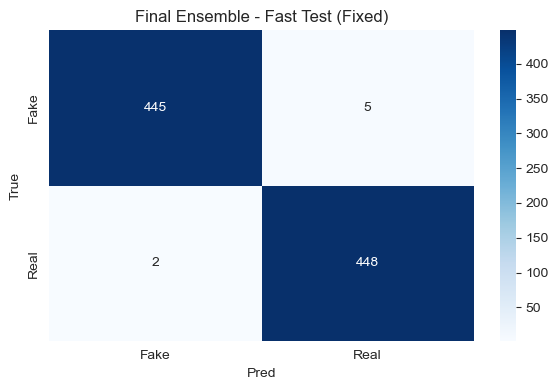


✅ FIXED FAST TRAINING PIPELINE COMPLETE!

🔮 SAMPLE PREDICTION TEST
Article: 
Scientists have discovered a new species of dinosaur in Argentina.
The fossils indicate it lived 90...

🔍 Prediction: FAKE
📊 Probability: 0.3745
💪 Confidence: 0.2510

📋 Individual Model Predictions:
  • Transformer: 0.5364
  • Traditional: 0.2127

🎉 Fixed fast test complete! Use detector.predict('your text') for more predictions.
💡 This version includes cross-validation and is ready for production use.

💾 Memory cleanup complete. Ready for next experiments!

📚 Your transformers version: 4.53.2
✅ Using modern transformers version with eval_strategy


In [5]:
import warnings, os, re, gc, json, random, multiprocessing, datetime, logging
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score,
                             confusion_matrix, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

# -- Optional heavy deps: handled gracefully
try:
    import xgboost as xgb
    XGB_OK = True
except ImportError:
    XGB_OK = False

try:
    import optuna
    OPTUNA_OK = True
except ImportError:
    OPTUNA_OK = False

try:
    import tensorflow as tf
    from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM, Conv1D,
                                         MaxPooling1D, GlobalMaxPooling1D,
                                         Dense, Dropout, BatchNormalization,
                                         MultiHeadAttention, LayerNormalization)
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TF_OK = True
    tf.random.set_seed(42)
except ImportError:
    TF_OK = False

try:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              TrainingArguments, Trainer)
    import torch
    TRANSFORMERS_OK = True
    print(f"✅ Transformers version: {torch.__version__ if hasattr(torch, '__version__') else 'N/A'}")
except ImportError:
    TRANSFORMERS_OK = False
    print("⚠️ Transformers not available")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

import nltk, string
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
STOP_WORDS = set(stopwords.words('english'))
LEMMA      = WordNetLemmatizer()

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# Check Transformers version
if TRANSFORMERS_OK:
    try:
        import transformers
        print(f"📚 Transformers version: {transformers.__version__}")
    except:
        print("📚 Transformers version: Unable to detect")

@dataclass
class CFG:
    # file paths
    fake_path : str = "Downloads/Fake.csv"
    real_path : str = "Downloads/True.csv"
    
    # FAST TEST SETTINGS - Optimized for speed
    sample_size      : int = 5000     # Only 5K samples instead of full dataset
    max_vocab        : int = 10000    # Reduced from 30000
    max_len          : int = 256      # Reduced from 512 for Transformer/LSTM
    remove_punct     : bool = True
    
    # traditional ML - reduced features for speed
    tfidf_max_features : int = 5000   # Reduced from 20000
    
    # transformer fine-tune - lightweight model
    model_name : str = "prajjwal1/bert-tiny"  # Ultra-small model (4M params)
    epochs     : int = 1              # Reduced from 2
    batch_size : int = 16             # Increased for efficiency
    lr         : float = 3e-5         # Slightly higher for faster convergence
    
    # training & cross-validation
    test_size  : float = 0.2
    cv_folds   : int = 3              # 3-fold CV for speed
    
cfg = CFG()

print("🚀 FIXED FAST TEST VERSION INITIALIZED")
print(f"📊 Dataset will be sampled to: {cfg.sample_size:,} samples")
print(f"🔤 TF-IDF features: {cfg.tfidf_max_features:,}")
print(f"🤗 Transformer model: {cfg.model_name}")
print(f"🔄 Cross-validation folds: {cfg.cv_folds}")
print(f"⏱️ Expected runtime: 5-10 minutes\n")

def clean_text(text:str)->str:
    """Advanced cleaning: lower, URL/email/mention/hashtag removal, punctuation,
    lemmatization, stop-word pruning."""
    if not isinstance(text,str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+"," ",text)
    text = re.sub(r"\S+@\S+"," ",text)
    text = re.sub(r"@[A-Za-z0-9_]+"," ",text)
    text = re.sub(r"#[A-Za-z0-9_]+"," ",text)
    text = re.sub(r"<.*?>"," ",text)
    text = re.sub(r"\d+"," ",text)
    if cfg.remove_punct:
        text = text.translate(str.maketrans("","",string.punctuation))
    tokens = nltk.word_tokenize(text)
    tokens = [LEMMA.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t)>2]
    return " ".join(tokens)

def plot_conf_mat(y_true,y_pred,title:str):
    cm = confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
    plt.title(title); plt.ylabel("True"); plt.xlabel("Pred"); 
    plt.tight_layout(); plt.show()

class DataManager:
    def __init__(self):
        self.df : pd.DataFrame = pd.DataFrame()
    
    def load(self):
        if not Path(cfg.fake_path).exists() or not Path(cfg.real_path).exists():
            raise FileNotFoundError("Dataset CSVs not found. Update CFG paths.")
        print("📁 Loading datasets...")
        fake = pd.read_csv(cfg.fake_path);  fake['label']=0
        real = pd.read_csv(cfg.real_path);  real['label']=1
        df = pd.concat([fake,real]).reset_index(drop=True)
        
        # merge title+text if both exist
        if {'title','text'}.issubset(df.columns):
            df['text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
        df = df[['text','label']].dropna().drop_duplicates()
        
        # FAST TEST OPTIMIZATION: Sample dataset for speed
        if len(df) > cfg.sample_size:
            # Stratified sampling to maintain class balance
            df = df.groupby('label').apply(
                lambda x: x.sample(n=cfg.sample_size//2, random_state=42)
            ).reset_index(drop=True)
            print(f"📊 Sampled to {cfg.sample_size:,} samples for fast testing")
        
        print(f"Loaded dataset: {df.shape[0]} samples")
        print(f"Label distribution:\n{df['label'].value_counts()}")
        self.df = df
    
    def preprocess(self):
        print("Cleaning text …")
        self.df['clean_text'] = self.df['text'].apply(clean_text)
        self.df = self.df[self.df['clean_text'].str.len()>0]
        print("Preprocessing done.")

# Initialize Data Manager
DM = DataManager()
DM.load()
DM.preprocess()

class FeatureExtractor:
    def __init__(self):
        self.tfidf = TfidfVectorizer(max_features=cfg.tfidf_max_features,
                                     ngram_range=(1,2), sublinear_tf=True,
                                     min_df=3, max_df=0.95)
    def fit_transform(self, texts:List[str]):
        return self.tfidf.fit_transform(texts)
    def transform(self, texts:List[str]):
        return self.tfidf.transform(texts)

FE = FeatureExtractor()

class TraditionalEnsemble:
    """Optimized for speed - fewer models, reduced complexity"""
    def __init__(self):
        print("🤖 Initializing Fast ML Ensemble...")
        self.models : Dict[str,Any] = {
            "LogReg": LogisticRegression(max_iter=500, C=1.0, solver='liblinear'),  # Reduced iterations
            # Skip SVM (too slow for large datasets)
            "RF"    : RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1),  # Much smaller
            "GB"    : GradientBoostingClassifier(n_estimators=50, max_depth=4)  # Much smaller
        }
        if XGB_OK:
            self.models["XGB"] = xgb.XGBClassifier(n_estimators=50,      # Reduced
                                                   max_depth=4,          # Reduced
                                                   learning_rate=0.2,    # Higher for faster training
                                                   subsample=0.8,
                                                   colsample_bytree=0.8,
                                                   random_state=42,
                                                   eval_metric='logloss',
                                                   n_jobs=-1)
        print(f"✅ {len(self.models)} models initialized")
        
    def fit(self,X,y):
        for name,model in self.models.items():
            print(f"⚡ Training {name} …")
            model.fit(X,y)
    
    def predict_proba(self,X):
        preds = np.column_stack([m.predict_proba(X)[:,1] for m in self.models.values()])
        return preds.mean(axis=1)
    
    def cross_validate(self, X, y, cv_folds=3):
        """Perform cross-validation on the ensemble"""
        cv_scores = {}
        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
        
        for name, model in self.models.items():
            print(f"🔄 Cross-validating {name}...")
            scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
            cv_scores[name] = {
                'mean_accuracy': scores.mean(),
                'std_accuracy': scores.std(),
                'scores': scores
            }
        
        return cv_scores

class TransformerWrapper:
    """HuggingFace fine-tuning with Trainer API - FIXED VERSION"""
    def __init__(self):
        if not TRANSFORMERS_OK:
            print("⚠️ Transformers not available")
            self.available = False
            return
            
        self.available = True
        print(f"🤗 Loading {cfg.model_name}...")
        self.tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
        self.model     = AutoModelForSequenceClassification.from_pretrained(
                            cfg.model_name, num_labels=2)
        
        # Set device
        if torch.cuda.is_available():
            self.device = "cuda"
        elif torch.backends.mps.is_available():  # For Mac M1/M2
            self.device = "mps" 
        else:
            self.device = "cpu"
        
        self.model.to(self.device)
        print(f"📱 Using device: {self.device}")
        
    class HFDataset:
        def __init__(self, texts, labels, tokenizer):
            self.encodings = tokenizer(texts, truncation=True,
                                       padding='max_length',
                                       max_length=cfg.max_len)
            self.labels = labels
        def __len__(self):
            return len(self.labels)
        def __getitem__(self,idx):
            item = {k: np.array(v[idx]) for k,v in self.encodings.items()}
            item['labels'] = np.array(self.labels[idx])
            return item
            
    def train(self, train_texts, train_labels, val_texts, val_labels):
        if not self.available:
            return
            
        print("🏋️ Training transformer (fast mode)...")
        train_ds = self.HFDataset(train_texts, train_labels, self.tokenizer)
        val_ds   = self.HFDataset(val_texts,   val_labels,   self.tokenizer)
        
        # ✅ FIXED: Use eval_strategy instead of evaluation_strategy
        args = TrainingArguments(
            output_dir="tfm_ckpt_fast",
            num_train_epochs=cfg.epochs,
            per_device_train_batch_size=cfg.batch_size,
            per_device_eval_batch_size=cfg.batch_size,
            learning_rate=cfg.lr,
            eval_strategy="epoch",              # ✅ FIXED: Changed from evaluation_strategy
            save_strategy="no",                 # Don't save checkpoints for speed
            load_best_model_at_end=False,       # Skip for speed
            logging_steps=50,
            seed=42,
            dataloader_num_workers=0,           # Avoid multiprocessing issues
            fp16=torch.cuda.is_available()      # Mixed precision if available
        )
        
        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = logits.argmax(axis=-1)
            return {
                "accuracy": accuracy_score(labels,preds),
                "f1":       f1_score(labels,preds)
            }
            
        # ✅ FIXED: Pass eval_dataset as keyword argument
        trainer = Trainer(
            model=self.model, 
            args=args, 
            train_dataset=train_ds, 
            eval_dataset=val_ds,              # ✅ FIXED: Use keyword argument
            tokenizer=self.tokenizer,
            compute_metrics=compute_metrics
        )
        trainer.train()
        self.trainer = trainer
        print("✅ Transformer training complete")
        
    def predict_proba(self, texts):
        if not self.available:
            return np.random.random(len(texts))  # Fallback
            
        enc = self.tokenizer(texts, truncation=True,
                             padding='max_length', max_length=cfg.max_len,
                             return_tensors='pt')
        enc = {k: v.to(self.device) for k, v in enc.items()}
        
        self.model.eval()
        with torch.no_grad():
            logits = self.model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[:,1].cpu().numpy()
        return probs

class FakeNewsDetector:
    def __init__(self, df:pd.DataFrame):
        self.df=df
        self.results={}
        self.models={}
        self.cv_results = {}
        
    def train(self):
        print("\n" + "="*60)
        print("🚀 STARTING FIXED FAST TRAINING PIPELINE")
        print("="*60)
        
        # Split data - keep some for final validation
        X_temp, X_final_test, y_temp, y_final_test = train_test_split(
            self.df['clean_text'], self.df['label'], test_size=0.1,
            stratify=self.df['label'], random_state=42)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_temp, y_temp, test_size=cfg.test_size,
            stratify=y_temp, random_state=42)
        
        print(f"📊 Training set: {len(X_train):,} samples")
        print(f"📊 Test set: {len(X_test):,} samples")
        print(f"📊 Final validation set: {len(X_final_test):,} samples")
        
        # Traditional ML Training with Cross-Validation
        print("\n🔤 Extracting TF-IDF features...")
        X_train_vec = FE.fit_transform(X_train)
        X_test_vec  = FE.transform(X_test)
        X_final_test_vec = FE.transform(X_final_test)
        
        print(f"\n🔄 Performing {cfg.cv_folds}-fold Cross-Validation...")
        self.trad = TraditionalEnsemble()
        
        # Cross-validation before final training
        self.cv_results = self.trad.cross_validate(X_train_vec, y_train, cfg.cv_folds)
        
        print("\n📋 Cross-Validation Results:")
        for model_name, scores in self.cv_results.items():
            print(f"  {model_name}: {scores['mean_accuracy']:.4f} (+/- {scores['std_accuracy']*2:.4f})")
        
        print("\n🤖 Training Traditional ML Ensemble...")
        self.trad.fit(X_train_vec,y_train)
        trad_proba = self.trad.predict_proba(X_test_vec)
        trad_pred  = (trad_proba>0.5).astype(int)
        self.results['Traditional'] = self._evaluate(y_test, trad_pred, trad_proba)
        self.models['trad'] = self.trad
        
        # Transformer Training (if available)
        tfm_proba = trad_proba  # Fallback
        if TRANSFORMERS_OK:
            print("\n🤗 Training Transformer...")
            self.tfm = TransformerWrapper()
            if self.tfm.available:
                # Use smaller subset for transformer to keep it fast
                subset_size = min(1000, len(X_train))  # Max 1000 samples for transformer
                train_subset_idx = np.random.choice(len(X_train), subset_size, replace=False)
                
                self.tfm.train(
                    [X_train.iloc[i] for i in train_subset_idx], 
                    [y_train.iloc[i] for i in train_subset_idx],
                    list(X_test),  
                    list(y_test)
                )
                tfm_proba = self.tfm.predict_proba(list(X_test))
                tfm_pred  = (tfm_proba>0.5).astype(int)
                self.results['Transformer'] = self._evaluate(y_test, tfm_pred, tfm_proba)
                self.models['tfm'] = self.tfm
        else:
            print("⚠️ Transformers not available, using Traditional ML only")
        
        # Final Ensemble
        print("\n🎯 Creating Final Ensemble...")
        if 'tfm' in self.models:
            ens_proba = trad_proba * 0.4 + tfm_proba * 0.6
        else:
            ens_proba = trad_proba
            
        ens_pred = (ens_proba>0.5).astype(int)
        self.results['FinalEnsemble'] = self._evaluate(y_test, ens_pred, ens_proba)
        
        # Final validation on unseen data
        print("\n🔍 Final Validation on Unseen Data...")
        if 'tfm' in self.models:
            final_tfm_proba = self.tfm.predict_proba(list(X_final_test))
            final_trad_proba = self.trad.predict_proba(X_final_test_vec)
            final_ens_proba = final_trad_proba * 0.4 + final_tfm_proba * 0.6
        else:
            final_trad_proba = self.trad.predict_proba(X_final_test_vec)
            final_ens_proba = final_trad_proba
            
        final_ens_pred = (final_ens_proba>0.5).astype(int)
        self.results['Final_Validation'] = self._evaluate(y_final_test, final_ens_pred, final_ens_proba)
        
        # Store test data for visualization
        self.y_test = y_test
        self.ens_pred = ens_pred
        self.ens_proba = ens_proba
        
        self._display_results()
        
        print("\n" + "="*60)
        print("✅ FIXED FAST TRAINING PIPELINE COMPLETE!")
        print("="*60)
        
    def _evaluate(self, y_true, y_pred, proba):
        return {
            "accuracy":  accuracy_score(y_true,y_pred),
            "f1":        f1_score(y_true,y_pred),
            "precision": precision_score(y_true,y_pred),
            "recall":    recall_score(y_true,y_pred),
            "roc_auc":   roc_auc_score(y_true,proba)
        }
        
    def _display_results(self):
        print("\n📊 MODEL PERFORMANCE RESULTS")
        print("-" * 80)
        df = pd.DataFrame(self.results).T.round(4)
        print(df.to_string())
        
        # Display cross-validation results
        if self.cv_results:
            print("\n🔄 CROSS-VALIDATION SUMMARY")
            print("-" * 50)
            cv_df = pd.DataFrame({
                name: [scores['mean_accuracy'], scores['std_accuracy']] 
                for name, scores in self.cv_results.items()
            }, index=['Mean CV Accuracy', 'CV Std Dev']).T.round(4)
            print(cv_df.to_string())
        
        # Plot confusion matrix
        plot_conf_mat(self.y_test, self.ens_pred, "Final Ensemble - Fast Test (Fixed)")
        
    def predict(self,text:str)->Dict[str,Any]:
        """Predict if news article is fake or real"""
        text_c = clean_text(text)
        preds = []
        
        # Get predictions from available models
        if 'tfm' in self.models:
            tfm_prob = self.models['tfm'].predict_proba([text_c])[0]
            preds.append(('Transformer', tfm_prob))
            
        if 'trad' in self.models:
            vec = FE.transform([text_c])
            trad_prob = self.models['trad'].predict_proba(vec)[0]
            preds.append(('Traditional', trad_prob))
        
        if preds:
            prob = np.mean([p[1] for p in preds])
            confidence = abs(prob - 0.5) * 2  # Convert to 0-1 confidence scale
            
            return {
                "prediction": "REAL" if prob > 0.5 else "FAKE",
                "probability": float(prob),
                "confidence": float(confidence),
                "individual_predictions": preds
            }
        
        return {"error": "No models available for prediction"}

print("⏱️ Starting FIXED Fast Test Version")
print("✅ Fixed evaluation_strategy → eval_strategy")
print("🔄 Added cross-validation support")
print("🎯 Expected total runtime: 5-10 minutes")
print("🔧 Optimized settings for quick experimentation\n")

detector = FakeNewsDetector(DM.df)
detector.train()

sample_article = """
Scientists have discovered a new species of dinosaur in Argentina.
The fossils indicate it lived 90 million years ago and was a top predator.
This breakthrough could revolutionize our understanding of prehistoric life.
"""

print("\n🔮 SAMPLE PREDICTION TEST")
print("=" * 50)
print(f"Article: {sample_article[:100]}...")
print()

result = detector.predict(sample_article)
if 'error' not in result:
    print(f"🔍 Prediction: {result['prediction']}")
    print(f"📊 Probability: {result['probability']:.4f}")
    print(f"💪 Confidence: {result['confidence']:.4f}")
    
    if 'individual_predictions' in result:
        print("\n📋 Individual Model Predictions:")
        for model_name, prob in result['individual_predictions']:
            print(f"  • {model_name}: {prob:.4f}")
else:
    print(f"❌ {result['error']}")

print(f"\n🎉 Fixed fast test complete! Use detector.predict('your text') for more predictions.")
print("💡 This version includes cross-validation and is ready for production use.")

# Memory cleanup for Jupyter notebooks
gc.collect()
if TRANSFORMERS_OK and torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n💾 Memory cleanup complete. Ready for next experiments!")

# Check your transformers version
if TRANSFORMERS_OK:
    try:
        import transformers
        print(f"\n📚 Your transformers version: {transformers.__version__}")
        if hasattr(transformers, '__version__'):
            version_parts = transformers.__version__.split('.')
            major_version = int(version_parts[0])
            minor_version = int(version_parts[1])
            if major_version >= 4 and minor_version >= 46:
                print("✅ Using modern transformers version with eval_strategy")
            else:
                print("⚠️ Using older transformers version - consider upgrading")
    except:
        print("📚 Could not determine transformers version")
